##**Telco Customer Churn - Exploratory Data Analysis**

###*Exploration des facteurs associés au churn client avant l'analyse SQL et la visualisation Power BI.*

##**1. Contexte**

Dans le secteur des télécommunications, la fidélisation des clients constitue
un enjeu important. L'objectif de cette analyse est d'explorer les données
clients afin d'identifier les principales caractéristiques associées au
désabonnement (`Churn`).

##Cette analyse constitue la première étape d'un projet Data Analyst réalisé avec :
 **Python → SQL → Power BI**

Objectifs de l'analyse Python

- Comprendre la structure et la qualité du dataset
- Explorer le taux global de churn
- Identifier les premières variables associées au désabonnement
- Formuler des hypothèses à approfondir avec SQL
- Préparer l'identification de segments de clients pouvant faire l'objet
  d'actions de rétention

**Important :** cette analyse est descriptive et exploratoire. Les associations observées ne permettent pas d'établir de lien de causalité.

##**2. Importation des librairies**



In [3]:
from google.colab import files
uploaded = files.upload()

Saving Dataset_Telco_customer_churn_VF.csv to Dataset_Telco_customer_churn_VF.csv


In [4]:
#Librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#Import du dataset

df = pd.read_csv('Dataset_Telco_customer_churn_VF.csv')
# Copie du dataset
df1 = df.copy()

##**3. Découverte du dataset**

In [26]:
#Aperçu
num_rows, num_columns = df.shape
print(f"Le dataset comporte {num_rows} lignes et {num_columns} colonnes.")

Le dataset comporte 7043 lignes et 21 colonnes.


##**4. Aperçu  des données**

In [9]:
# Afficher les informations générales sur le DataFrame (colonnes, types de données, valeurs non nulles)
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df1.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##**6. Liste des variables**


In [8]:
# Colonnes du dataset:
for columns in df1.columns:
  print(columns)

customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [21]:
#Découvrir les variables catégorielle
col_categorielle = df1.select_dtypes(include='object').columns # connaître les colonnes dont le type est 'object'
for columns in col_categorielle:
    print(f"\n--- {columns} ---") # affiche le nom de la colonne le "\n" ajoute une  ligne vide par souci d'affichage
    print(df1[columns].value_counts(normalize=True).mul(100).map('{:.2f}%'.format))#compte le nb d'occurence de valeurs unique, value_counts(normalize=true) permet d'avoir des proportions


--- customerID ---
customerID
3186-AJIEK    0.01%
7590-VHVEG    0.01%
5575-GNVDE    0.01%
8775-CEBBJ    0.01%
2823-LKABH    0.01%
              ...  
6713-OKOMC    0.01%
1452-KIOVK    0.01%
9305-CDSKC    0.01%
9237-HQITU    0.01%
7795-CFOCW    0.01%
Name: proportion, Length: 7043, dtype: object

--- gender ---
gender
Male      50.48%
Female    49.52%
Name: proportion, dtype: object

--- Partner ---
Partner
No     51.70%
Yes    48.30%
Name: proportion, dtype: object

--- Dependents ---
Dependents
No     70.04%
Yes    29.96%
Name: proportion, dtype: object

--- PhoneService ---
PhoneService
Yes    90.32%
No      9.68%
Name: proportion, dtype: object

--- MultipleLines ---
MultipleLines
No                  48.13%
Yes                 42.18%
No phone service     9.68%
Name: proportion, dtype: object

--- InternetService ---
InternetService
Fiber optic    43.96%
DSL            34.37%
No             21.67%
Name: proportion, dtype: object

--- OnlineSecurity ---
OnlineSecurity
No             

##**7. Statistiques descriptives**

In [7]:
# Afficher les statistiques descriptives pour les colonnes numériques
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


##**8. Doublons**

In [33]:
num_duplicates = df1.duplicated().sum()

print(f"Nombre de lignes dupliquées : {num_duplicates}")

Nombre de lignes dupliquées : 0


In [20]:
#Savoir s'il y a des doublons de lignes
num_duplicates = df1.duplicated().sum()
print(f"Le dataset contient {num_duplicates} lignes en double.")

Le dataset contient 0 lignes en double.


##**9. Nettoyage de TotalCharges**

## Conversion de 'TotalCharges'

La variable 'TotalCharges' représente le montant total facturé au client,
mais elle est importée comme variable textuelle ('object').

Nous allons la convertir en variable numérique et identifier les valeurs
qui ne peuvent pas être converties.

On remarque que la colonne TotalCharges est de type object au lieu de numérique.

In [8]:
# Changement de type de la colonne de 'TotalCharges'
df1['TotalCharges'] = pd.to_numeric(df1['TotalCharges'], errors='coerce')
print(f"Nombre de valeurs manquantes (NaN) dans 'TotalCharges' : {df1['TotalCharges'].isnull().sum()}")

Nombre de valeurs manquantes (NaN) dans 'TotalCharges' : 11


##**10. Remplacement par 0**

Les 11 valeurs non convertibles correspondent aux clients ayant une
ancienneté de 0 mois. Dans le contexte de ce dataset, elles sont considérées
comme des clients nouvellement inscrits n'ayant pas encore de facturation
cumulée.

`TotalCharges` est donc remplacée par 0 pour ces observations.

In [9]:
# On remplace les valeurs manquantes
df1['TotalCharges'] = df1['TotalCharges'].fillna(0)
print(f"Nombre de valeurs manquantes (NaN) dans 'TotalCharges' : {df1['TotalCharges'].isna().sum()}")

Nombre de valeurs manquantes (NaN) dans 'TotalCharges' : 0


On remplace par "0", car ces 11 clients viennent de s'inscrire( tenure = 0) et n'ont pas encore de facturation cumulée.

In [11]:
#Pourcentage de valeurs manquantes par colonnes
pct_missing = df1[['SeniorCitizen','tenure','MonthlyCharges','TotalCharges','Churn']].isnull().sum() * 100 / len(df1)
pct_missing = pct_missing.map('{:.2f}%'.format)#map('{:.2f}%'.format) #permet de formater en pourcentage avec 2 décimales.
pct_missing

,0
SeniorCitizen,0.00%
tenure,0.00%
MonthlyCharges,0.00%
TotalCharges,0.00%
Churn,0.00%


##**11. Taux de Churn**

### Taux global de désabonnement

Avant d'étudier les caractéristiques des clients, nous établissons le taux
global de churn qui servira de référence pour les analyses suivantes.

In [17]:
#Analyse du Churn (Désabonnement)
df1['Churn'].value_counts(normalize=True).mul(100).map('{:.2f}%'.format)
churn_rate = df1['Churn'].value_counts(normalize=True)['Yes']
print(f"Le taux de désabonnement est de {churn_rate * 100:.2f}%")


Le taux de désabonnement est de 26.54%


Le taux global de churn est de **26,54 %** : environ un client sur quatre
a quitté l'opérateur dans le dataset.

Ce taux constitue notre référence pour comparer les différents profils de
clients dans la suite de l'analyse.

##Analyse exploratoire du Churn

In [18]:
# Identifions les profils de clients qui quittent l'entreprise (en réalisant des analyses bivariées)

# Transformons la colonne Churn en 0 et 1
df1['Churn_num'] = df1['Churn'].map({'No': 0, 'Yes': 1})

#Matrice de corrélation
corr = df1[['Churn_num', 'tenure', 'MonthlyCharges', 'TotalCharges','SeniorCitizen']].corr()#selectionne les variables.calcule la corrélation.garde slmt la corrélation avec Churn_num, par ordre décroissant.
print(corr)

                Churn_num    tenure  MonthlyCharges  TotalCharges  \
Churn_num        1.000000 -0.352229        0.193356     -0.198324   
tenure          -0.352229  1.000000        0.247900      0.826178   
MonthlyCharges   0.193356  0.247900        1.000000      0.651174   
TotalCharges    -0.198324  0.826178        0.651174      1.000000   
SeniorCitizen    0.150889  0.016567        0.220173      0.103006   

                SeniorCitizen  
Churn_num            0.150889  
tenure               0.016567  
MonthlyCharges       0.220173  
TotalCharges         0.103006  
SeniorCitizen        1.000000  


Il existe une relation négative faible entre l'ancienneté et le churn, les clients avec une **grande ancienneté** ont tendance **à moins se désabonner**

La matrice de corrélation permet d'identifier quelques signaux exploratoires, notamment une relation négative entre l'ancienneté et le churn. Ces résultats doivent toutefois être interprétés avec prudence, car la corrélation ne permet pas d'établir une causalité.

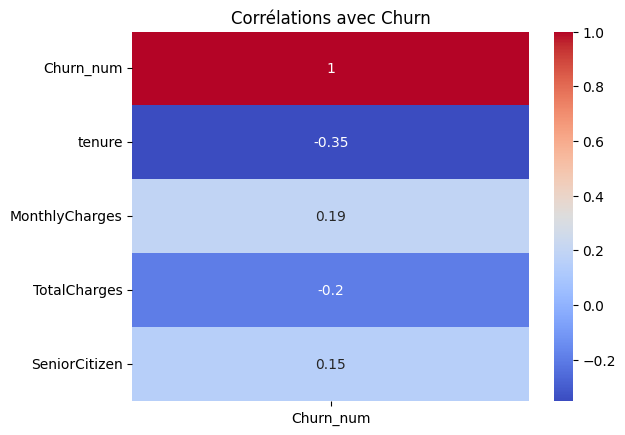

In [19]:
# Heatmap de corrélation
corr_churn = df1[['Churn_num', 'tenure', 'MonthlyCharges', 'TotalCharges','SeniorCitizen']].corr()[['Churn_num']]
sns.heatmap(corr_churn, annot=True, cmap='coolwarm')
plt.title('Corrélations avec Churn')
plt.show()

Le graphique confirme la relation linéaire négative entre l'ancienneté et le désabonnement : plus un client à de l'ancienneté et moins il se désabonne.

##**12. Analyse du type de contrat**

Le type de contrat décrit la durée d'engagement du client auprès de l'opérateur. Nous allons comparer le taux de churn entre les différents types de contrat afin d'identifier d'éventuelles différences de comportement

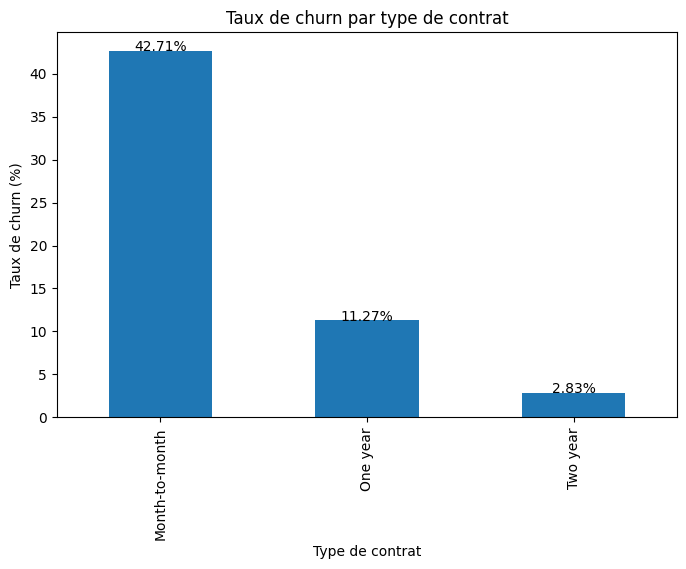

In [7]:

churn_by_contract = df1.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100)

ax = churn_by_contract.plot(kind='bar', figsize=(8, 5))

plt.title('Taux de churn par type de contrat')
plt.xlabel('Type de contrat')
plt.ylabel('Taux de churn (%)')
## Ajouter des pourcentags:
for i, valeur in enumerate(churn_by_contract):
    plt.text(i, valeur, f'{valeur:.2f}%', ha='center')

plt.show()

Les clients en contrat **Month-to-month** présentent un taux de churn de **42,71 %**, contre **11,28 %** pour les contrats d'un an et **2,83 %** pour les contrats de deux ans. Le contrat mensuel apparaît donc comme un premier signal fortement associé au churn. Cette observation conduit à examiner plus précisément le profil et l'ancienneté des clients, notamment chez les clients récemment inscrits.

In [8]:
#Afficher les volumes des nb_clients et nb_churn.
contract_summary = (df1.groupby('Contract').agg(nb_clients=('customerID', 'nunique'),nb_churn=('Churn', lambda x: (x == 'Yes').sum())))

contract_summary['churn_rate'] = (contract_summary['nb_churn']
    / contract_summary['nb_clients']
    * 100)

contract_summary.sort_values(
    'churn_rate',
    ascending=False
)

,nb_clients,nb_churn,churn_rate
Contract,,,
Month-to-month,3875,1655,42.709677
One year,1473,166,11.269518
Two year,1695,48,2.831858


###**13. Analyse de l'ancienneté**

L'ancienneté (`tenure`) correspond au nombre de mois depuis l'arrivée du client chez l'opérateur. L'analyse précédente a montré que le taux de churn semble diminuer lorsque l'ancienneté augmente. Nous allons regrouper les clients en cinq catégories d'ancienneté afin de mieux comparer les taux de churn entre les différents profils.

Les groupes retenus sont :
- 0–6 mois
- 7–12 mois
- 13–24 mois
- 25–48 mois
- 49+ mois

In [9]:
##Créer des groupes
bins = [-1, 6, 12, 24, 48, np.inf]# limites des catégories
labels = ['0–6 mois', '7–12 mois', '13–24 mois', '25–48 mois', '49+ mois']

df1['tenure_group'] = pd.cut(df1['tenure'], bins, labels=labels)

resultat = df1['tenure_group'].value_counts().sort_index()

print(resultat)


tenure_group
0–6 mois      1481
7–12 mois      705
13–24 mois    1024
25–48 mois    1594
49+ mois      2239
Name: count, dtype: int64


In [11]:
churn_by_tenure = (df1.groupby('tenure_group', observed=True)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100).round(2))

churn_by_tenure

,Churn
tenure_group,
0–6 mois,52.94
7–12 mois,35.89
13–24 mois,28.71
25–48 mois,20.39
49+ mois,9.51


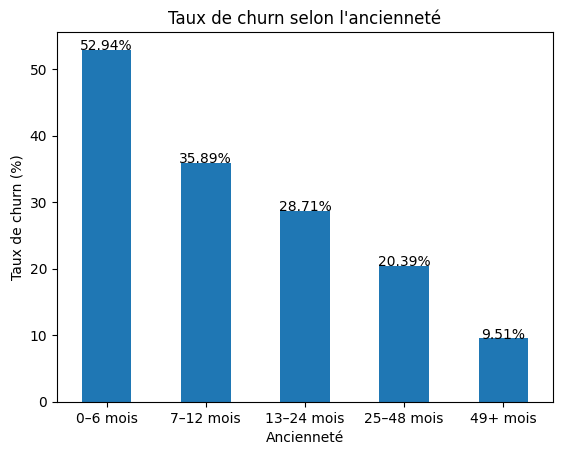

In [12]:
# Faire le graphique
ax = churn_by_tenure.plot(kind='bar')

# Ajouter les informations
plt.title("Taux de churn selon l'ancienneté")
plt.xlabel("Ancienneté")
plt.ylabel("Taux de churn (%)")

# Écrire les pourcentages
for i, valeur in enumerate(churn_by_tenure):
    plt.text(i, valeur, f"{valeur:.2f}%", ha="center")

# Afficher
plt.xticks(rotation=0)
plt.show()


### Observation

Le taux de churn diminue nettement avec l'ancienneté.

Il atteint environ **53 % chez les clients ayant moins de 7 mois
d'ancienneté**, contre environ **10 % chez les clients ayant 49 mois ou
plus**.

Les clients les plus récents apparaissent donc comme un profil
particulièrement associé au churn.

Cette observation renforce l'hypothèse selon laquelle les premiers mois de
la relation client constituent une période importante à surveiller.

##**14. Répartition de l'ancienneté par type de contrat**

L'analyse précédente montre que les clients ayant moins de 7 mois d'ancienneté présentent le taux de churn le plus élevé.
Nous allons maintenant examiner leur profil contractuel afin de déterminer si les nouveaux clients sont principalement engagés sur des contrats Month-to-month.

In [14]:
contract_by_tenure = pd.crosstab(
    df1['tenure_group'],
    df1['Contract'],
    normalize='index').round(2) * 100

contract_by_tenure

Contract,Month-to-month,One year,Two year
tenure_group,,,
0–6 mois,95.0,3.0,2.0
7–12 mois,82.0,12.0,6.0
13–24 mois,72.0,19.0,9.0
25–48 mois,50.0,32.0,17.0
49+ mois,15.0,28.0,56.0
